# Imorts

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

%matplotlib inline
sns.set(style="whitegrid")

# Load data

In [8]:
# Load the pre-split datasets
train_df = pd.read_csv('dataset_train.csv')
test_df = pd.read_csv('dataset_test.csv')

print(f"Training Set Shape: {train_df.shape}")
print(f"Testing Set Shape:  {test_df.shape}")

Training Set Shape: (520, 37)
Testing Set Shape:  (192, 37)


# Preproccessing

In [9]:
# Separate Features (X) and Target (y) for TRAINING set
X_train = train_df.iloc[:, :-1] 
y_train_raw = train_df.iloc[:, -1]

# Separate Features (X) and Target (y) for TESTING set
X_test = test_df.iloc[:, :-1]
y_test_raw = test_df.iloc[:, -1]

# Encode Labels
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)

try:
    y_test = le.transform(y_test_raw)
except ValueError as e:
    print("Warning: Unseen labels in test set. Handling required.")
    raise e

print("Classes found:", le.classes_)
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape},  y_test shape:  {y_test.shape}")

Classes found: ['German' 'Italian' 'Korean' 'Spanish']
X_train shape: (520, 36), y_train shape: (520,)
X_test shape:  (192, 36),  y_test shape:  (192,)


# Feature selection

In [10]:
# Standardize features by removing the mean and scaling to unit variance
scaler = StandardScaler()

# Fit on training set only to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Dimensionality Reduction

In [27]:
# Apply PCA to reduce dimensions (optional step mentioned in the project)
# We keep 85% of the variance
pca = PCA(n_components=0.85)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original feature count: {X_train.shape[1]}")
print(f"Reduced feature count (85% variance): {X_train_pca.shape[1]}")

Original feature count: 36
Reduced feature count (85% variance): 9


# Model Training helper function

In [19]:
# A dictionary to store results for comparison
model_results = {}

def train_evaluate_model(model, model_name, X_tr, y_tr, X_te, y_te):
    """
    Trains a model, predicts on test set, and prints evaluation metrics.
    """
    print(f"--- Training {model_name} ---")
    
    # Train the model
    model.fit(X_tr, y_tr)
    
    # Predict
    y_pred = model.predict(X_te)
    
    # Calculate metrics
    acc = accuracy_score(y_te, y_pred)
    model_results[model_name] = acc
    
    print(f"{model_name} Accuracy: {acc:.4f}")
    print("\nClassification Report:\n")
    print(classification_report(y_te, y_pred, target_names=le.classes_))
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.grid(False)
    plt.show()
    print("-" * 50)

# KNN

--- Training K-Nearest Neighbors ---
K-Nearest Neighbors Accuracy: 0.9948

Classification Report:

              precision    recall  f1-score   support

      German       1.00      0.98      0.99        42
     Italian       0.98      1.00      0.99        51
      Korean       1.00      1.00      1.00        53
     Spanish       1.00      1.00      1.00        46

    accuracy                           0.99       192
   macro avg       1.00      0.99      0.99       192
weighted avg       0.99      0.99      0.99       192



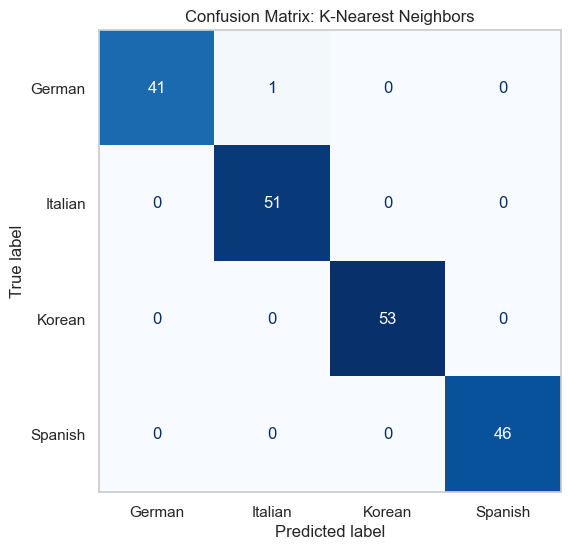

--------------------------------------------------


In [20]:
# KNN Algorithm
knn = KNeighborsClassifier(n_neighbors=5)
train_evaluate_model(knn, "K-Nearest Neighbors", X_train_pca, y_train, X_test_pca, y_test)

# SVM (RBF kernel)

--- Training Support Vector Machine ---
Support Vector Machine Accuracy: 0.9896

Classification Report:

              precision    recall  f1-score   support

      German       1.00      0.98      0.99        42
     Italian       0.96      1.00      0.98        51
      Korean       1.00      0.98      0.99        53
     Spanish       1.00      1.00      1.00        46

    accuracy                           0.99       192
   macro avg       0.99      0.99      0.99       192
weighted avg       0.99      0.99      0.99       192



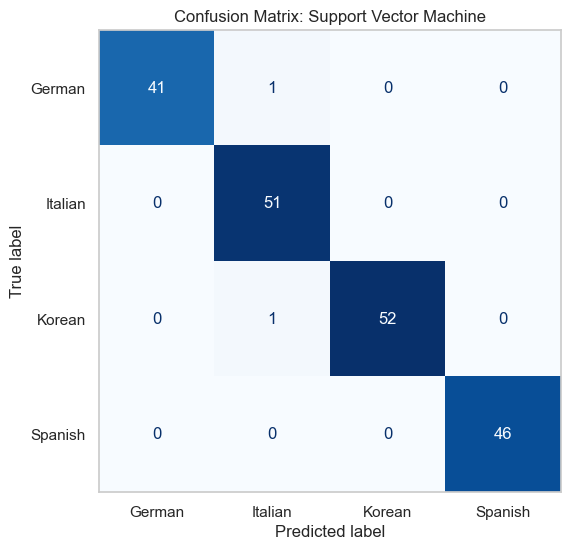

--------------------------------------------------


In [21]:
# SVM Algorithm with RBF kernel
svm = SVC(kernel='rbf', C=1.0, random_state=42)
train_evaluate_model(svm, "Support Vector Machine", X_train_pca, y_train, X_test_pca, y_test)

# Random Forest

--- Training Random Forest ---


Random Forest Accuracy: 0.9531

Classification Report:

              precision    recall  f1-score   support

      German       0.95      0.90      0.93        42
     Italian       0.89      0.98      0.93        51
      Korean       0.98      0.94      0.96        53
     Spanish       1.00      0.98      0.99        46

    accuracy                           0.95       192
   macro avg       0.96      0.95      0.95       192
weighted avg       0.96      0.95      0.95       192



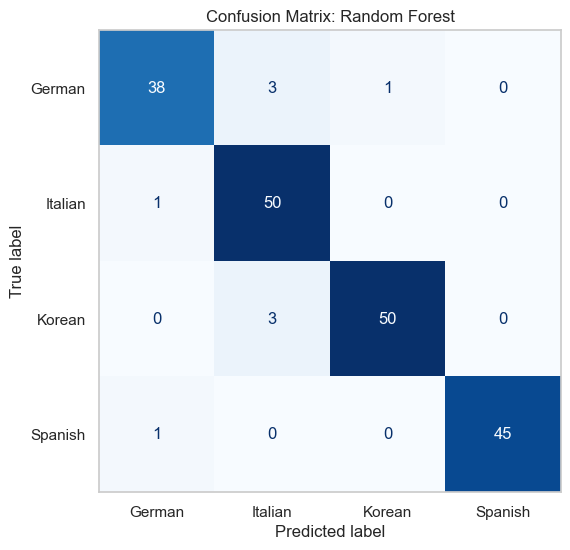

--------------------------------------------------


In [22]:
# Random Forest Algorithm
rf = RandomForestClassifier(n_estimators=100, random_state=42)
train_evaluate_model(rf, "Random Forest", X_train_pca, y_train, X_test_pca, y_test)

# Model Comparision

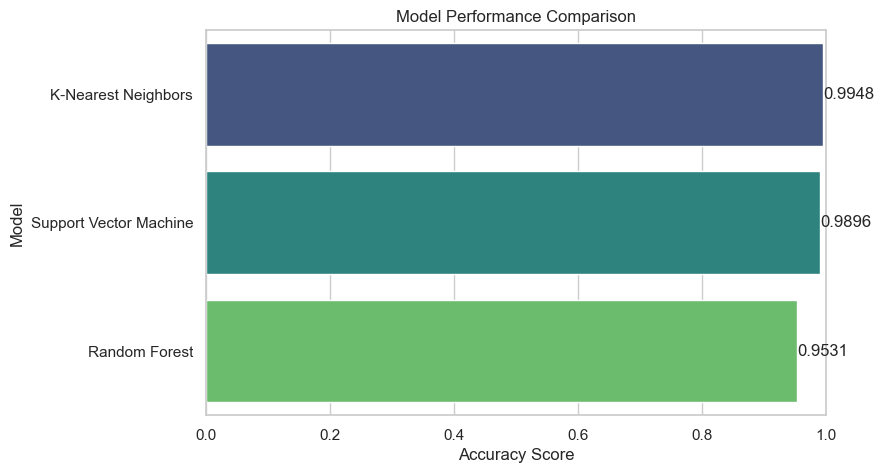

In [36]:
# Compare the accuracies of all trained models
results_df = pd.DataFrame(list(model_results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis', hue='Model', legend=False)
plt.xlim(0, 1.0)
plt.title("Model Performance Comparison")
plt.xlabel("Accuracy Score")
plt.ylabel("Model")
for index, value in enumerate(results_df['Accuracy']):
    plt.text(value, index, f'{value:.4f}', va='center')
plt.show()

# Saving Trained models and processed dataset

In [30]:
import joblib

# Save the trained models
print("Saving models...")
joblib.dump(knn, 'knn_model.pkl')
joblib.dump(svm, 'svm_model.pkl')
joblib.dump(rf, 'rf_model.pkl')

# Save the processed test data (X_test_pca) and labels (y_test)
np.save('X_test_processed.npy', X_test_pca)
np.save('y_test.npy', y_test)

# Save class names for the confusion matrix (['de', 'en', 'es', 'it'])
np.save('classes.npy', le.classes_)

print("All models and data saved successfully!")

Saving models...
All models and data saved successfully!
